# 01 · The functional-stochastic model for a single point

**Objective:** Reproduce the null hypothesis GLS fit ($E[y]=Ax, Q_{yy}=\sigma^2*R_{yy}$) for a single real point, and inspect the residuals.

Related blog post: https://jsempereh.github.io/notes/insar-functional-stochastic-model/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms


In [2]:
ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)
print(f"{len(ds.metadata)} points, {len(ds.dates)} epochs")

# Pick the point with the strongest linear trend: easiest to sanity-check visually
pid = ds.metadata.loc[ds.metadata["mean_velocity"].abs().idxmax(), "pid"]
t, y = egms.point_time_series(ds, pid)
print(f"point {pid}: {len(t)} epochs, {t[-1]:.2f} years span, EGMS mean_velocity = "
      f"{ds.metadata.loc[ds.metadata['pid'] == pid, 'mean_velocity'].iloc[0]} mm/yr")

38598 points, 210 epochs


point 48GPP2M1IM: 210 epochs, 4.98 years span, EGMS mean_velocity = -9.1 mm/yr


In [3]:
# H0: E[y] = A0 * v, Qyy = sigma^2 * I (Section III-A: fixed variance, uncorrelated observations)
A0 = library.design_matrix_h0(t)
sigma = 3.0  # mm, conservative a priori value (paper uses the same order of magnitude for TerraSAR-X)
Qyy = (sigma ** 2) * np.eye(len(t))
Qyy_inv = np.linalg.inv(Qyy)

fit = testing.gls_fit(y, A0, Qyy_inv)
v_hat = fit.x_hat[0]
print(f"GLS v_hat = {v_hat:.2f} mm/yr  (EGMS mean_velocity = "
      f"{ds.metadata.loc[ds.metadata['pid'] == pid, 'mean_velocity'].iloc[0]} mm/yr)")

GLS v_hat = -9.02 mm/yr  (EGMS mean_velocity = -9.1 mm/yr)


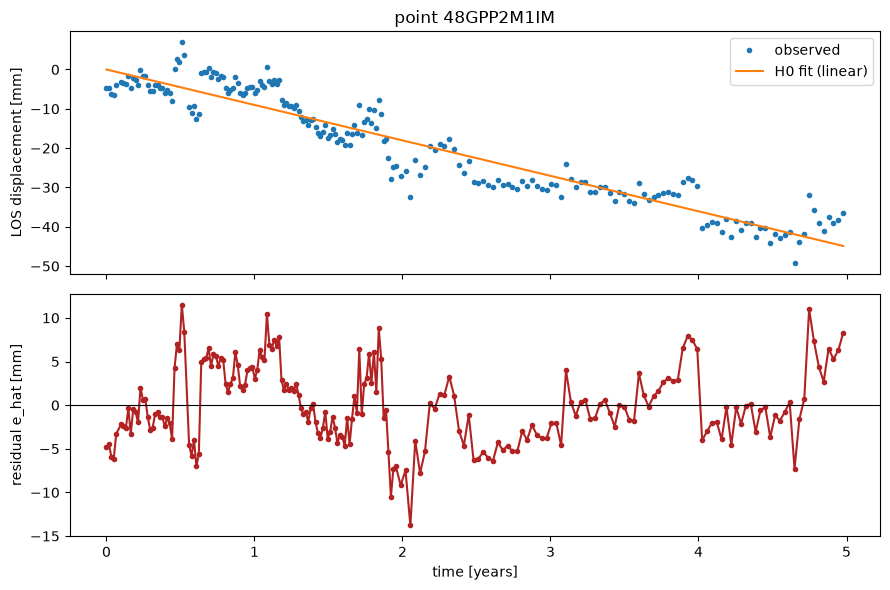

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, y, ".", label="observed")
axes[0].plot(t, fit.y_hat, "-", label="H0 fit (linear)")
axes[0].set_ylabel("LOS displacement [mm]")
axes[0].legend()
axes[0].set_title(f"point {pid}")

axes[1].plot(t, fit.e_hat, ".-", color="firebrick")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("time [years]")
axes[1].set_ylabel("residual e_hat [mm]")
plt.tight_layout()

## Does the residual look like pure noise?

A quick preview of notebook 02: the Overall Model Test (Eq. 10) answers this
with a single number. If the residual has structure beyond H0 (a season, a
step, a curve), T0 will land far above the chi-squared critical value.

In [5]:
from scipy import stats

alpha0 = 1 / (2 * len(t))  # Section II-E heuristic
q0 = len(t) - A0.shape[1]
T0 = testing.omt_statistic(fit.e_hat, Qyy_inv)
K = stats.chi2.ppf(1 - alpha0, q0)

print(f"T0 = {T0:.1f}, critical value K = {K:.1f} (alpha0={alpha0:.2e}, q0={q0})")
print("H0 REJECTED -> look for a better model in notebook 02" if T0 > K else "H0 sustained")

T0 = 443.9, critical value K = 271.4 (alpha0=2.38e-03, q0=209)
H0 REJECTED -> look for a better model in notebook 02
